# 05. A random walk per country

Notebook 04 found a shared year signal and showed it does nothing for the country-specific timing: CHN's hydro counts fall after 2015 while the model keeps rising, and the hydro country-year coverage stays 2 to 3 points over nominal. A year effect every country shares can only repair errors every country shares, and those turned out to be the minority.

This notebook gives each country its own random walk on top of the shared one. The country walks start at zero in 1981, so the country intercept keeps its meaning as the 1981 level, and their innovations sum to zero across countries in every year, so the shared walk keeps its meaning as the average movement and the country walks carry the departures from it. The step scale is one number per class, estimated, so a country cannot drift unless the panel as a whole says countries drift. The rest of the model is notebook 04 as it stands.

Sections follow the workflow: the data, the model, what the priors imply, the fit, its diagnostics, what the posterior predicts, the shared and country walks, between against within, the posterior against the prior, the comparison with the earlier notebooks, and what was learned.

In [1]:
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import pytensor.tensor as pt
import xarray as xr

from arviz_plots import plot_energy, plot_forest, plot_trace
from checks import (
    count_summaries,
    observed_count_summaries,
    plot_country_counts,
    plot_coverage,
    plot_posterior_with_prior,
    plot_predictive_summaries,
    plot_rootograms,
    plot_walk,
    summarize,
)

from climate_risk.plotting import configure_plot_style
from climate_risk.replication_data import MODEL_FEATURES, create_replication_data
from climate_risk.sample import sample_or_load
from climate_risk.stats.scaling import standardize

configure_plot_style()

In [2]:
PROJECT_ROOT = next(p for p in Path.cwd().parents if (p / "pyproject.toml").exists())
CACHE_DIR = PROJECT_ROOT / "data"
FIT_DIR = Path("fits")

SEED = sum(map(ord, "climate_bayes"))

CLASSES = ["climate", "hydro"]
COUNTS = {"climate": "climatological_disasters", "hydro": "hydrological_disasters"}
SHOWN_COUNTRIES = ["LAO", "CHN", "BGD"]

# The paper's covariates with population logged, less the square of GDP per capita.
FEATURES = [("ln_population" if name == "population" else name)
            for name in MODEL_FEATURES if name != "square_ln_gdp_pc"]

# The covariates that get a latent country mean: those that vary between countries.
CONFOUNDED = ["ln_population", "ln_population_density", "ln_gdp_pc"]

## The data

The same panel and indices as notebook 04.

In [3]:
panel = (create_replication_data(CACHE_DIR)
         .to_pandas()
         .rename(columns={"ISO": "iso"})
         .assign(ln_population=lambda frame: np.log(frame["population"]),
                 year=lambda frame: frame["date"].dt.year)
         .dropna(subset=FEATURES)
         .reset_index(drop=True))

counts = panel[[COUNTS[name] for name in CLASSES]].fillna(0.0).astype(int)
counts.columns = CLASSES

_, scaled = standardize(panel, FEATURES)
SCALED_FEATURES = [f"{name}__standardized" for name in FEATURES]

codes = sorted(panel["iso"].unique())
country_idx = panel["iso"].map({code: position for position, code in enumerate(codes)}).to_numpy()

# nutpie stores the coords, and it rejects numpy integers.
years = sorted(panel["year"].unique().tolist())
year_idx = panel["year"].map({year: position for position, year in enumerate(years)}).to_numpy()

print(f"{len(panel)} country-years, {len(codes)} countries, {years[0]} to {years[-1]}")

7710 country-years, 199 countries, 1981 to 2023


## The model

Notebook 04 with one term added to the log rate. Per class $c$, country $j$, year $t$, and country-year $i$ in country $j$ and year $t$,

$$
\begin{aligned}
\log \mu_{ic} &= a_c + v_{jc} + w_{tc} + z_{jtc} + \tilde{x}_i^\top \beta^{W}_c + u_j^\top \beta^{B}_c \\
z_{j1c} &= 0 \\
z_{jtc} &= z_{j,t-1,c} + \sigma^{Z}_c\, \eta_{jtc}, \quad \eta_{\cdot tc} \sim \operatorname{ZeroSumNormal}(1) \text{ over } j
\end{aligned}
$$

$z_{jtc}$ is the country walk. Its innovations $\eta_{jtc}$ are standard normals constrained to sum to zero across the 199 countries in each year and class, so the country walks carry no common movement and the shared walk $w_{tc}$ keeps all of it. The step scale $\sigma^{Z}_c$ carries a `HalfNormal(0.1)` prior, a tenth of a log unit a year, since the country intercept already holds each country's level and the walk only has to carry its movement about that level. As in notebook 04 the walks are scaled cumulative sums of their innovations.

The shared walk, the latents, the measurement model, the two coefficient vectors, and the country intercept are as in notebook 04, with the same priors.

In [4]:
coords = {
    "obs_idx": panel.index,
    "iso": codes,
    "year": years,
    "step": years[1:],
    "disaster": CLASSES,
    "feature": FEATURES,
    "confounded": CONFOUNDED,
    "confounded_": CONFOUNDED,
}
confounded_positions = [FEATURES.index(name) for name in CONFOUNDED]

with pm.Model(coords=coords) as country_walk_model:
    X = pm.Data("X", scaled[SCALED_FEATURES].to_numpy(), dims=["obs_idx", "feature"])
    country = pm.Data("country", country_idx, dims=["obs_idx"])
    year = pm.Data("year_of", year_idx, dims=["obs_idx"])

    # The covariates are standardized, so the latents carry the whole location: a free grand mean would trade
    # against them.
    latent_chol, latent_corr, latent_scale = pm.LKJCholeskyCov("latent_cov",
                                                              n=len(CONFOUNDED),
                                                              eta=2,
                                                              sd_dist=pm.HalfNormal.dist(1),
                                                              compute_corr=True)
    latent = pm.MvNormal("latent", mu=0, chol=latent_chol, dims=["iso", "confounded"])
    pm.Deterministic("latent_corr", latent_corr, dims=["confounded", "confounded_"])
    pm.Deterministic("latent_scale", latent_scale, dims=["confounded"])

    sigma_X = pm.Exponential("sigma_X", 1, dims=["confounded"])
    pm.Normal("X_hat",
              mu=latent[country],
              sigma=sigma_X,
              observed=X[:, confounded_positions],
              dims=["obs_idx", "confounded"])

    # The confounded columns enter the count as deviations from their latent, the rest as they are.
    X_within = pt.set_subtensor(X[:, confounded_positions], X[:, confounded_positions] - latent[country])

    intercept = pm.Normal("intercept", 0, 1, dims=["disaster"])
    beta_within = pm.Normal("beta_within", 0, 0.5, dims=["feature", "disaster"])
    beta_between = pm.Normal("beta_between", 0, 0.5, dims=["confounded", "disaster"])
    alpha = pm.Gamma("alpha", alpha=2, beta=1, dims=["disaster"])

    tau = pm.HalfNormal("tau", 1, dims=["disaster"])
    country_offset = pm.Normal("country_offset", 0, 1, dims=["iso", "disaster"])
    country_effect = pm.Deterministic("country_effect", tau * country_offset, dims=["iso", "disaster"])

    # Both walks start from zero in the first year, so the intercepts are first-year levels.
    sigma_year = pm.HalfNormal("sigma_year", 0.25, dims=["disaster"])
    year_innovation = pm.Normal("year_innovation", 0, 1, dims=["disaster", "step"])
    year_effect = pm.Deterministic("year_effect",
                                   pt.concatenate([pt.zeros((len(CLASSES), 1)),
                                                   pt.cumsum(sigma_year[:, None] * year_innovation, axis=1)],
                                                  axis=1),
                                   dims=["disaster", "year"])

    # ZeroSumNormal constrains its trailing axis, so the innovations sum to zero over countries within a year.
    sigma_country_walk = pm.HalfNormal("sigma_country_walk", 0.1, dims=["disaster"])
    country_innovation = pm.ZeroSumNormal("country_innovation", dims=["disaster", "step", "iso"])
    country_walk = pm.Deterministic("country_walk",
                                    pt.concatenate([pt.zeros((len(CLASSES), 1, len(codes))),
                                                    pt.cumsum(sigma_country_walk[:, None, None] * country_innovation,
                                                              axis=1)],
                                                   axis=1),
                                    dims=["disaster", "year", "iso"])

    log_mu = (intercept
              + country_effect[country]
              + year_effect.T[year]
              + country_walk[:, year, country].T
              + X_within @ beta_within
              + latent[country] @ beta_between)
    mu = pm.Deterministic("mu", pm.math.exp(log_mu), dims=["obs_idx", "disaster"])

    pm.NegativeBinomial("y",
                        mu=mu,
                        alpha=alpha,
                        observed=counts.to_numpy(),
                        dims=["obs_idx", "disaster"])

country_walk_model

                 X = Data(<shared>)
           country = Data(<shared>)
           year_of = Data(<shared>)
        latent_cov ~ _lkjcholeskycov(3, 2, HalfNormal(0, 1))
            latent ~ MultivariateNormal(f(latent_cov), f(latent_cov))
           sigma_X ~ Exponential(<constant>)
         intercept ~ Normal(0, 1)
       beta_within ~ Normal(0, 0.5)
      beta_between ~ Normal(0, 0.5)
             alpha ~ Gamma(2, <constant>)
               tau ~ HalfNormal(0, 1)
    country_offset ~ Normal(0, 1)
        sigma_year ~ HalfNormal(0, 0.25)
   year_innovation ~ Normal(0, 1)
sigma_country_walk ~ HalfNormal(0, 0.1)
country_innovation ~ ZeroSumNormal(1, <constant>)
   latent_cov_corr = Deterministic(f(latent_cov))
   latent_cov_stds = Deterministic(f(latent_cov))
       latent_corr = Deterministic(f(latent_cov_corr))
      latent_scale = Deterministic(f(latent_cov_stds))
    country_effect = Deterministic(f(country_offset, tau))
       year_effect = Deterministic(f(year_innovation, sigma_ye

## What the priors imply

The same three summaries as before. The country walk adds a second cumulative term, with a standard deviation of about 0.65 on the log rate by 2023 under its prior, on top of the shared walk's 1.6.

Sampling: [X_hat, alpha, beta_between, beta_within, country_innovation, country_offset, intercept, latent, latent_cov, sigma_X, sigma_country_walk, sigma_year, tau, y, year_innovation]


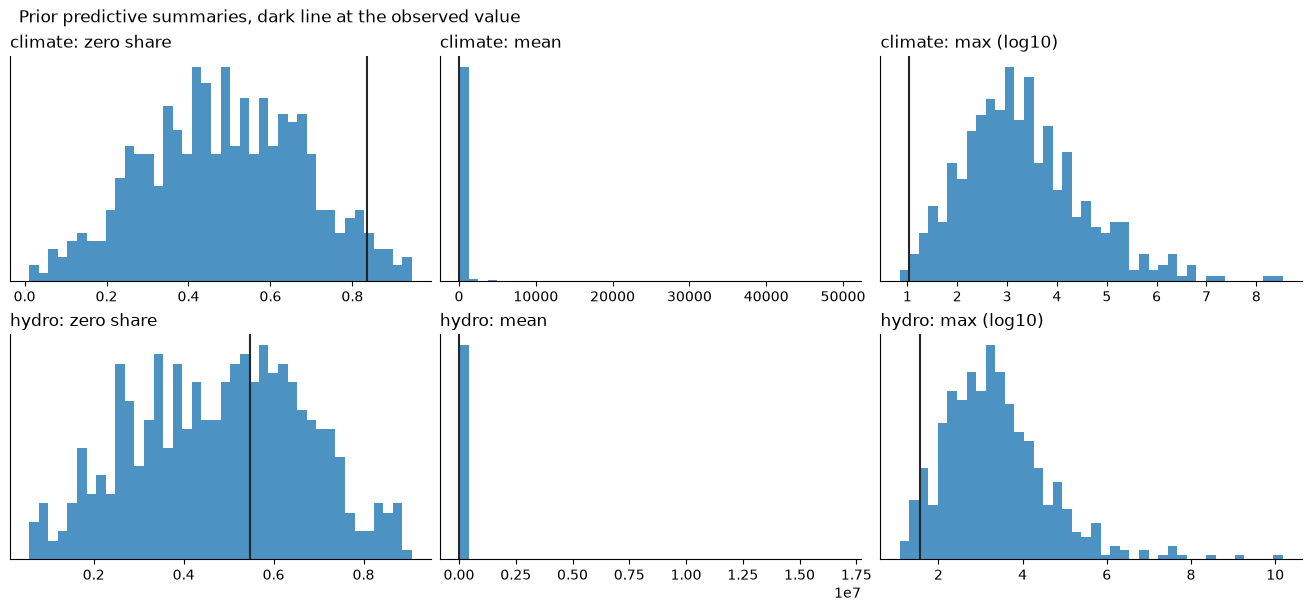

In [5]:
with country_walk_model:
    prior_idata = pm.sample_prior_predictive(draws=500, random_seed=SEED)

observed_summaries = observed_count_summaries(counts)
plot_predictive_summaries(count_summaries(prior_idata.prior_predictive["y"]),
                          observed_summaries,
                          CLASSES,
                          "Prior predictive summaries, dark line at the observed value")

## The fit

The draws land in `fits/`, which is gitignored. `sample_or_load` reads the file back when it exists and does not check that the saved draws came from the data now in memory, so a fit outlives any change to the panel or the feature list. Pass `force_resample=True` after one. The warmup draws are kept.

In [6]:
sample_kwargs = dict(chains=8,
                     cores=8,
                     tune=500,
                     draws=250,
                     discard_tuned_samples=False,
                     random_seed=SEED)

with country_walk_model:
    idata = sample_or_load(fp=str(FIT_DIR / "country_random_walk.nc"), sample_kwargs=sample_kwargs)

PARAMETERS = ["intercept", "beta_within", "beta_between", "latent_scale", "sigma_X", "alpha", "tau",
              "sigma_year", "sigma_country_walk"]
summarize(idata, PARAMETERS)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept[climate],-2.21,0.56,-3.11,-1.31,103.57,149.93,1.08,0.06,0.04
intercept[hydro],-0.90,0.33,-1.46,-0.39,48.76,87.21,1.13,0.05,0.04
"beta_within[ln_population_density, climate]",-0.65,0.35,-1.20,-0.09,1491.69,1616.65,1.00,0.01,0.01
"beta_within[ln_population_density, hydro]",0.88,0.32,0.37,1.39,525.43,788.74,1.02,0.01,0.01
"beta_within[ln_gdp_pc, climate]",-0.20,0.18,-0.50,0.09,1956.69,1473.57,1.00,0.00,0.00
"beta_within[ln_gdp_pc, hydro]",-0.19,0.12,-0.38,0.00,990.64,1199.22,1.00,0.00,0.00
"beta_within[precip_deviation, climate]",-0.41,0.04,-0.47,-0.35,3351.57,1551.57,1.00,0.00,0.00
"beta_within[precip_deviation, hydro]",0.24,0.01,0.21,0.26,4515.30,1752.08,1.00,0.00,0.00
"beta_within[co2, climate]",0.70,0.34,0.17,1.23,109.57,168.16,1.07,0.03,0.02
"beta_within[co2, hydro]",0.21,0.20,-0.13,0.50,48.00,83.91,1.13,0.03,0.02


## Diagnostics

The country walk adds 16,716 innovations, and its scale is the parameter to watch: a scale pulled toward zero with the innovations spread wide is the funnel the non-centered form is meant to avoid, and a scale that runs away is the walk taking over from the covariates. The innovations of both walks and the country offsets are summarized alongside the named parameters.

0 divergences; worst r_hat 1.131; smallest bulk ESS 48 (beta_within[co2, hydro])


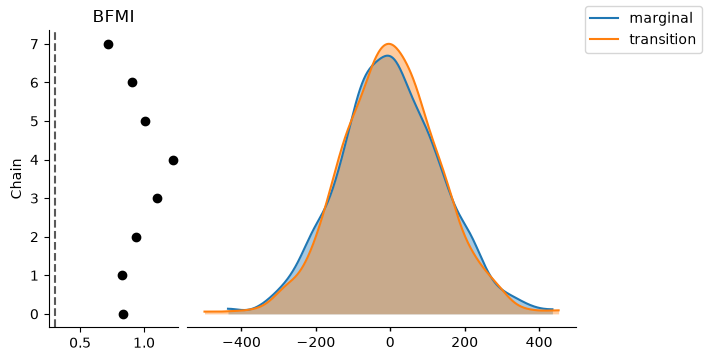

In [7]:
diagnostics = summarize(idata, [*PARAMETERS, "latent", "country_offset", "year_innovation", "country_innovation"])
diagnostics = diagnostics[["ess_bulk", "ess_tail", "r_hat"]]
divergences = int(idata.sample_stats["diverging"].sum())

print(f"{divergences} divergences; worst r_hat {diagnostics['r_hat'].max():.3f}; "
      f"smallest bulk ESS {diagnostics['ess_bulk'].min():.0f} ({diagnostics['ess_bulk'].idxmin()})")
plot_energy(idata, backend="matplotlib", figure_kwargs={"figsize": (7, 3.5)})
plt.show()

### Adaptation

The warmup traces of the three scales, one line per chain.

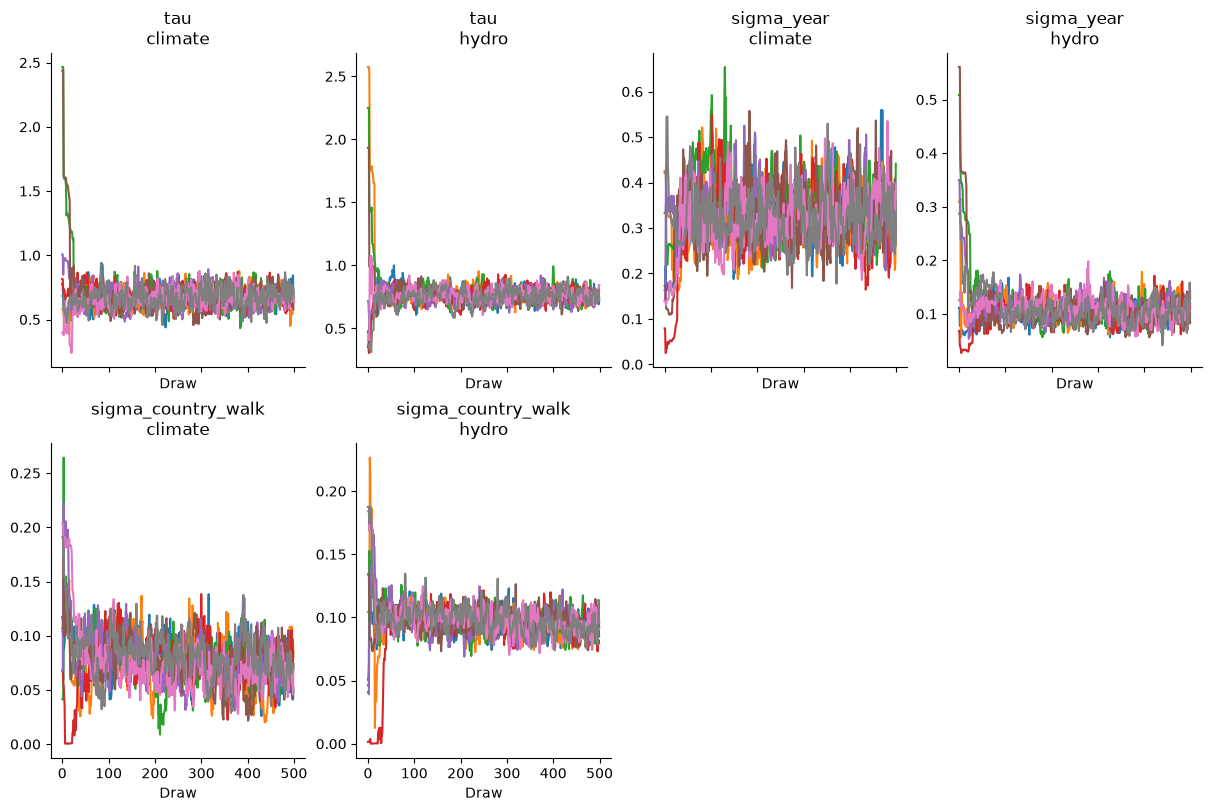

In [8]:
scales = idata.warmup_posterior.to_dataset()[["tau", "sigma_year", "sigma_country_walk"]]
plot_trace(xr.DataTree.from_dict({"posterior": scales}),
           backend="matplotlib",
           figure_kwargs={"figsize": (12, 8)})
plt.show()

## What the posterior predicts

The same three checks as before.

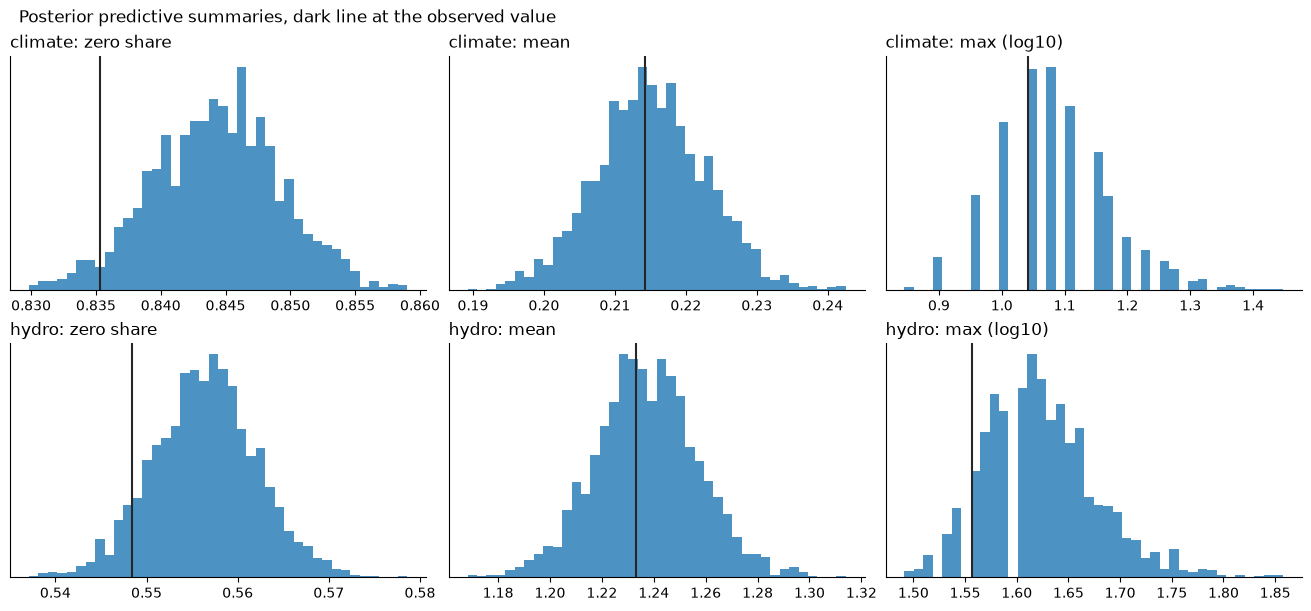

In [9]:
posterior_y = idata.posterior_predictive["y"]
plot_predictive_summaries(count_summaries(posterior_y),
                          observed_summaries,
                          CLASSES,
                          "Posterior predictive summaries, dark line at the observed value")

### The count distribution

Predicted frequency per count with its interval, observed as points, on a square-root axis.

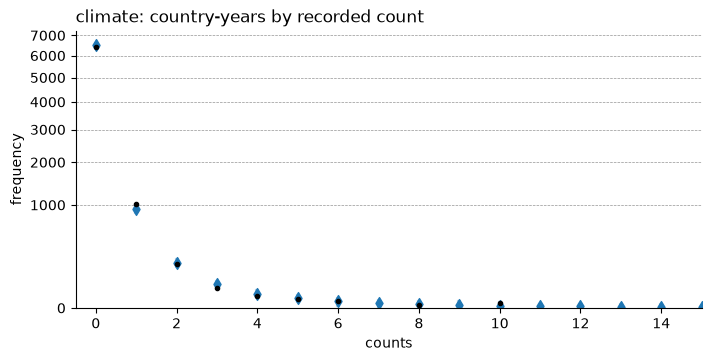

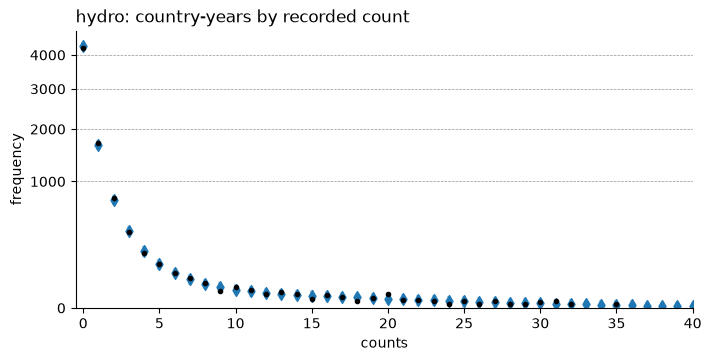

In [10]:
plot_rootograms(idata, counts, CLASSES)

### Interval coverage

Actual coverage minus nominal at every interval width, per country-year on the top row and per country total on the bottom, with the 99% band a calibrated model would produce. The country totals are over-covered by construction once each country has its own intercept, and a walk per country will push them further, since it fits each country's path as well as its level. The hydro country-year row is the one to compare with notebook 04.

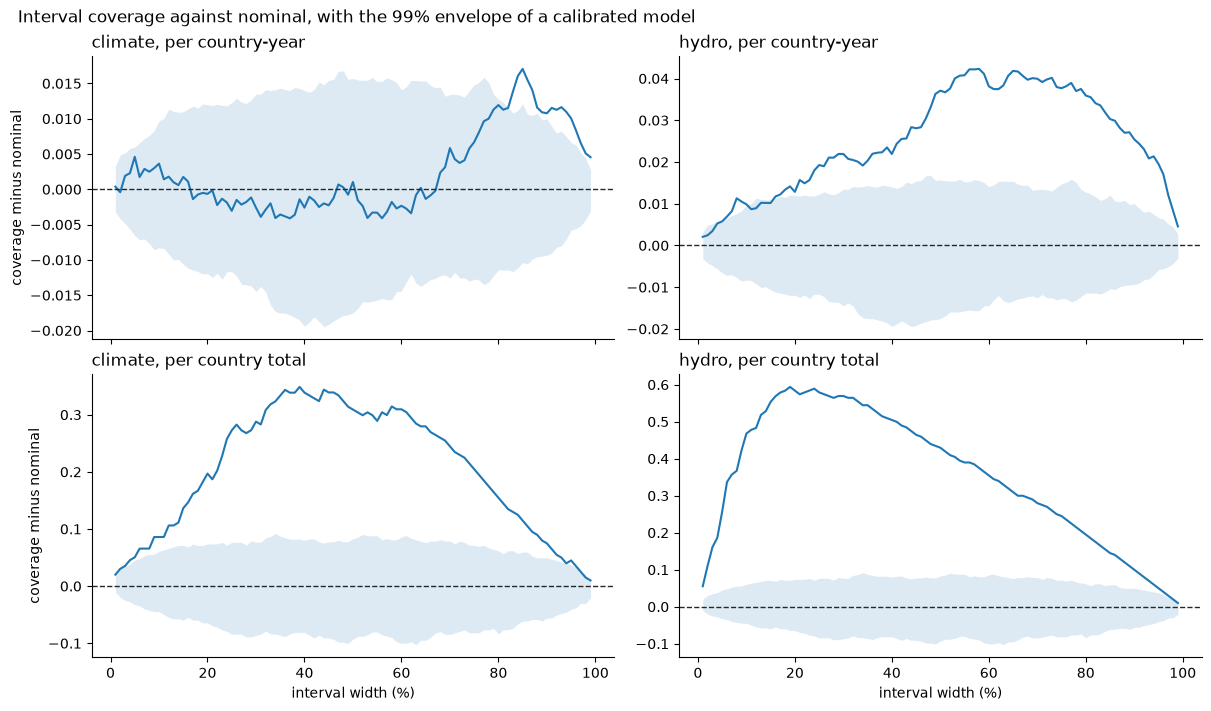

In [11]:
plot_coverage(idata, panel["iso"].to_numpy(), CLASSES)

## The shared walk

The posterior of $w_{tc}$ over years, one panel per class, with stacked central intervals, for comparison with notebook 04.

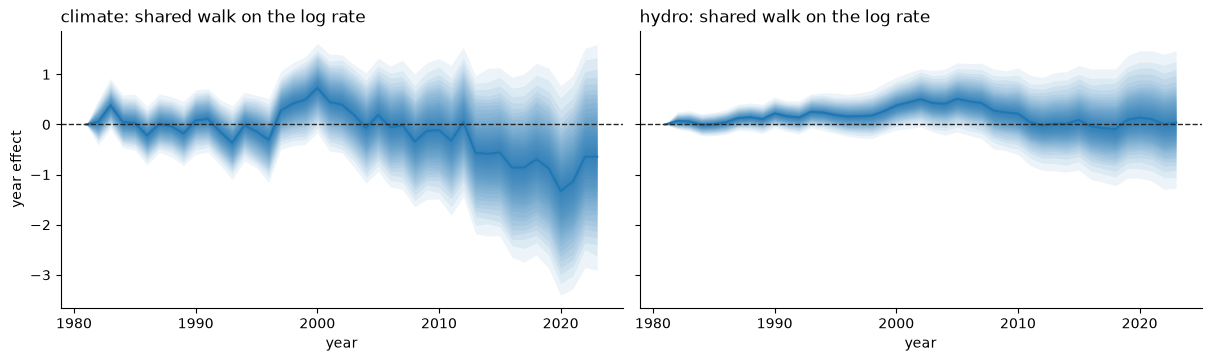

In [12]:
year_draws = idata.posterior["year_effect"].stack(sample=("chain", "draw"))
fig, axes = plt.subplots(1, len(CLASSES), figsize=(12, 3.5), sharey=True)

for axis, name in zip(axes, CLASSES, strict=True):
    plot_walk(axis, years, year_draws.sel(disaster=name), f"{name}: shared walk on the log rate")
    axis.set_xlabel("year")

axes[0].set_ylabel("year effect")
plt.show()

## The country walks

The same three countries as the count plots, with their departure from the shared walk. A country whose walk stays near zero is one the shared walk and the covariates already described.

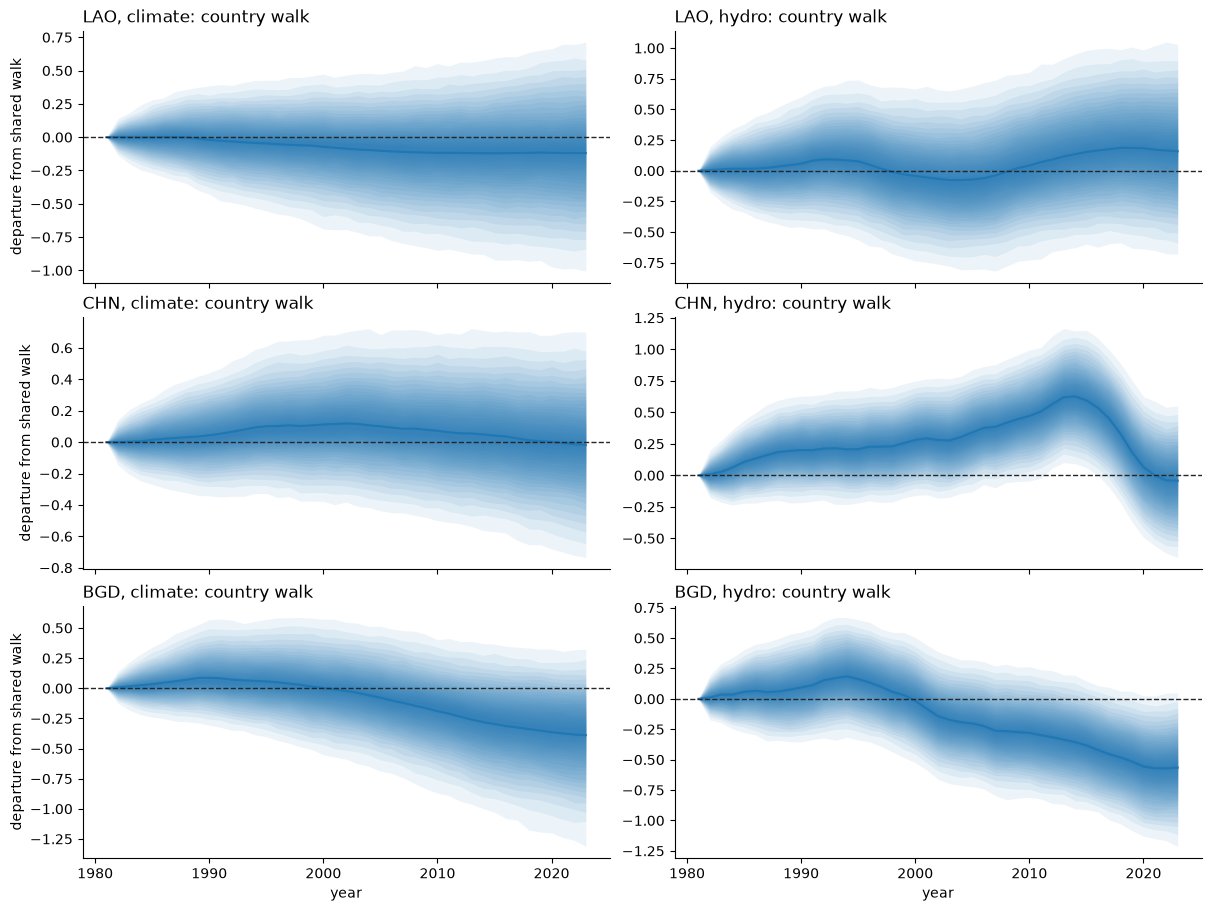

In [13]:
country_draws = idata.posterior["country_walk"].stack(sample=("chain", "draw"))
fig, axes = plt.subplots(len(SHOWN_COUNTRIES), len(CLASSES), figsize=(12, 3 * len(SHOWN_COUNTRIES)), sharex=True)

for iso, row in zip(SHOWN_COUNTRIES, axes, strict=True):
    for axis, name in zip(row, CLASSES, strict=True):
        plot_walk(axis, years, country_draws.sel(iso=iso, disaster=name), f"{iso}, {name}: country walk")

for axis in axes[:, 0]:
    axis.set_ylabel("departure from shared walk")
for axis in axes[-1]:
    axis.set_xlabel("year")
plt.show()

## Between against within

The slopes as in notebooks 03 and 04. The country walk can carry any country's trend, so the within slopes on the trending covariates, `co2` above all, are the ones to compare against notebook 04.

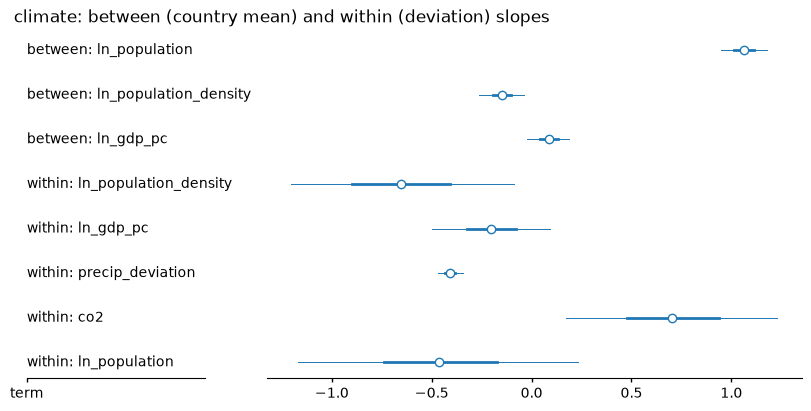

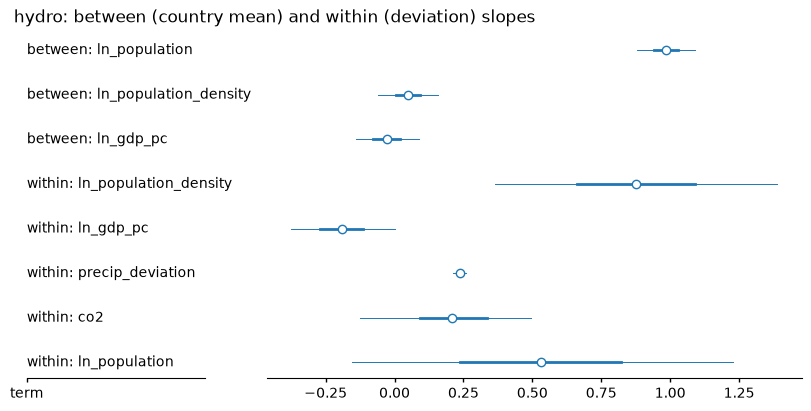

In [14]:
between = idata.posterior["beta_between"].rename(confounded="term")
between = between.assign_coords(term=[f"between: {name}" for name in between["term"].to_numpy()])
within = idata.posterior["beta_within"].rename(feature="term")
within = within.assign_coords(term=[f"within: {name}" for name in within["term"].to_numpy()])
slopes = xr.concat([between, within], dim="term").to_dataset(name="slope")

for name in CLASSES:
    grid = plot_forest(slopes,
                       coords={"disaster": name},
                       combined=True,
                       labels=["term"],
                       backend="matplotlib",
                       figure_kwargs={"figsize": (8, 4)})
    grid.viz["figure"].item().suptitle(f"{name}: between (country mean) and within (deviation) slopes",
                                       x=0.01,
                                       ha="left")
plt.show()

## A few countries over time

The same three countries, for comparison with notebooks 02 to 04.

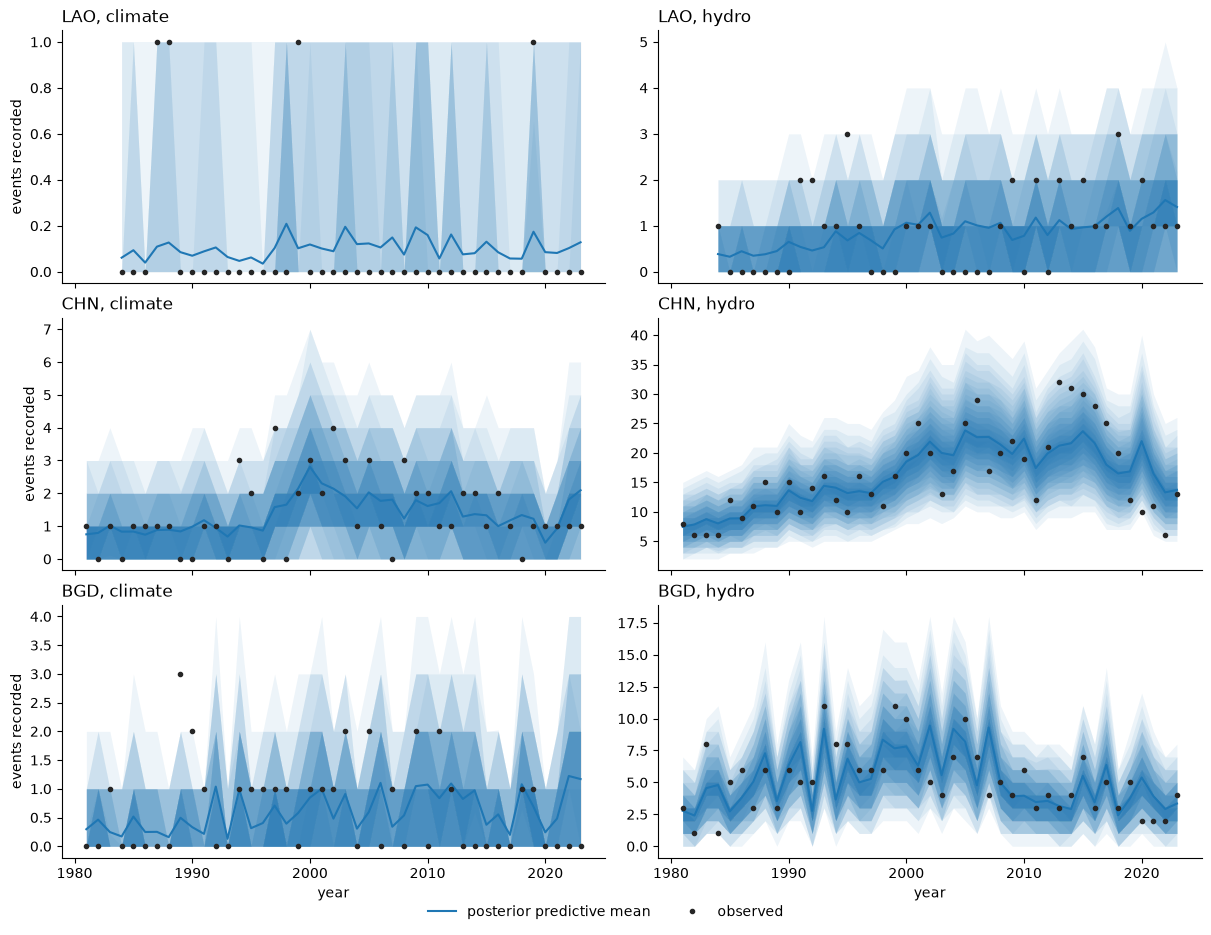

In [15]:
plot_country_counts(posterior_y, panel, counts, SHOWN_COUNTRIES, CLASSES)

## The posterior against the prior

Each panel is the posterior of one parameter in blue over its prior in orange.

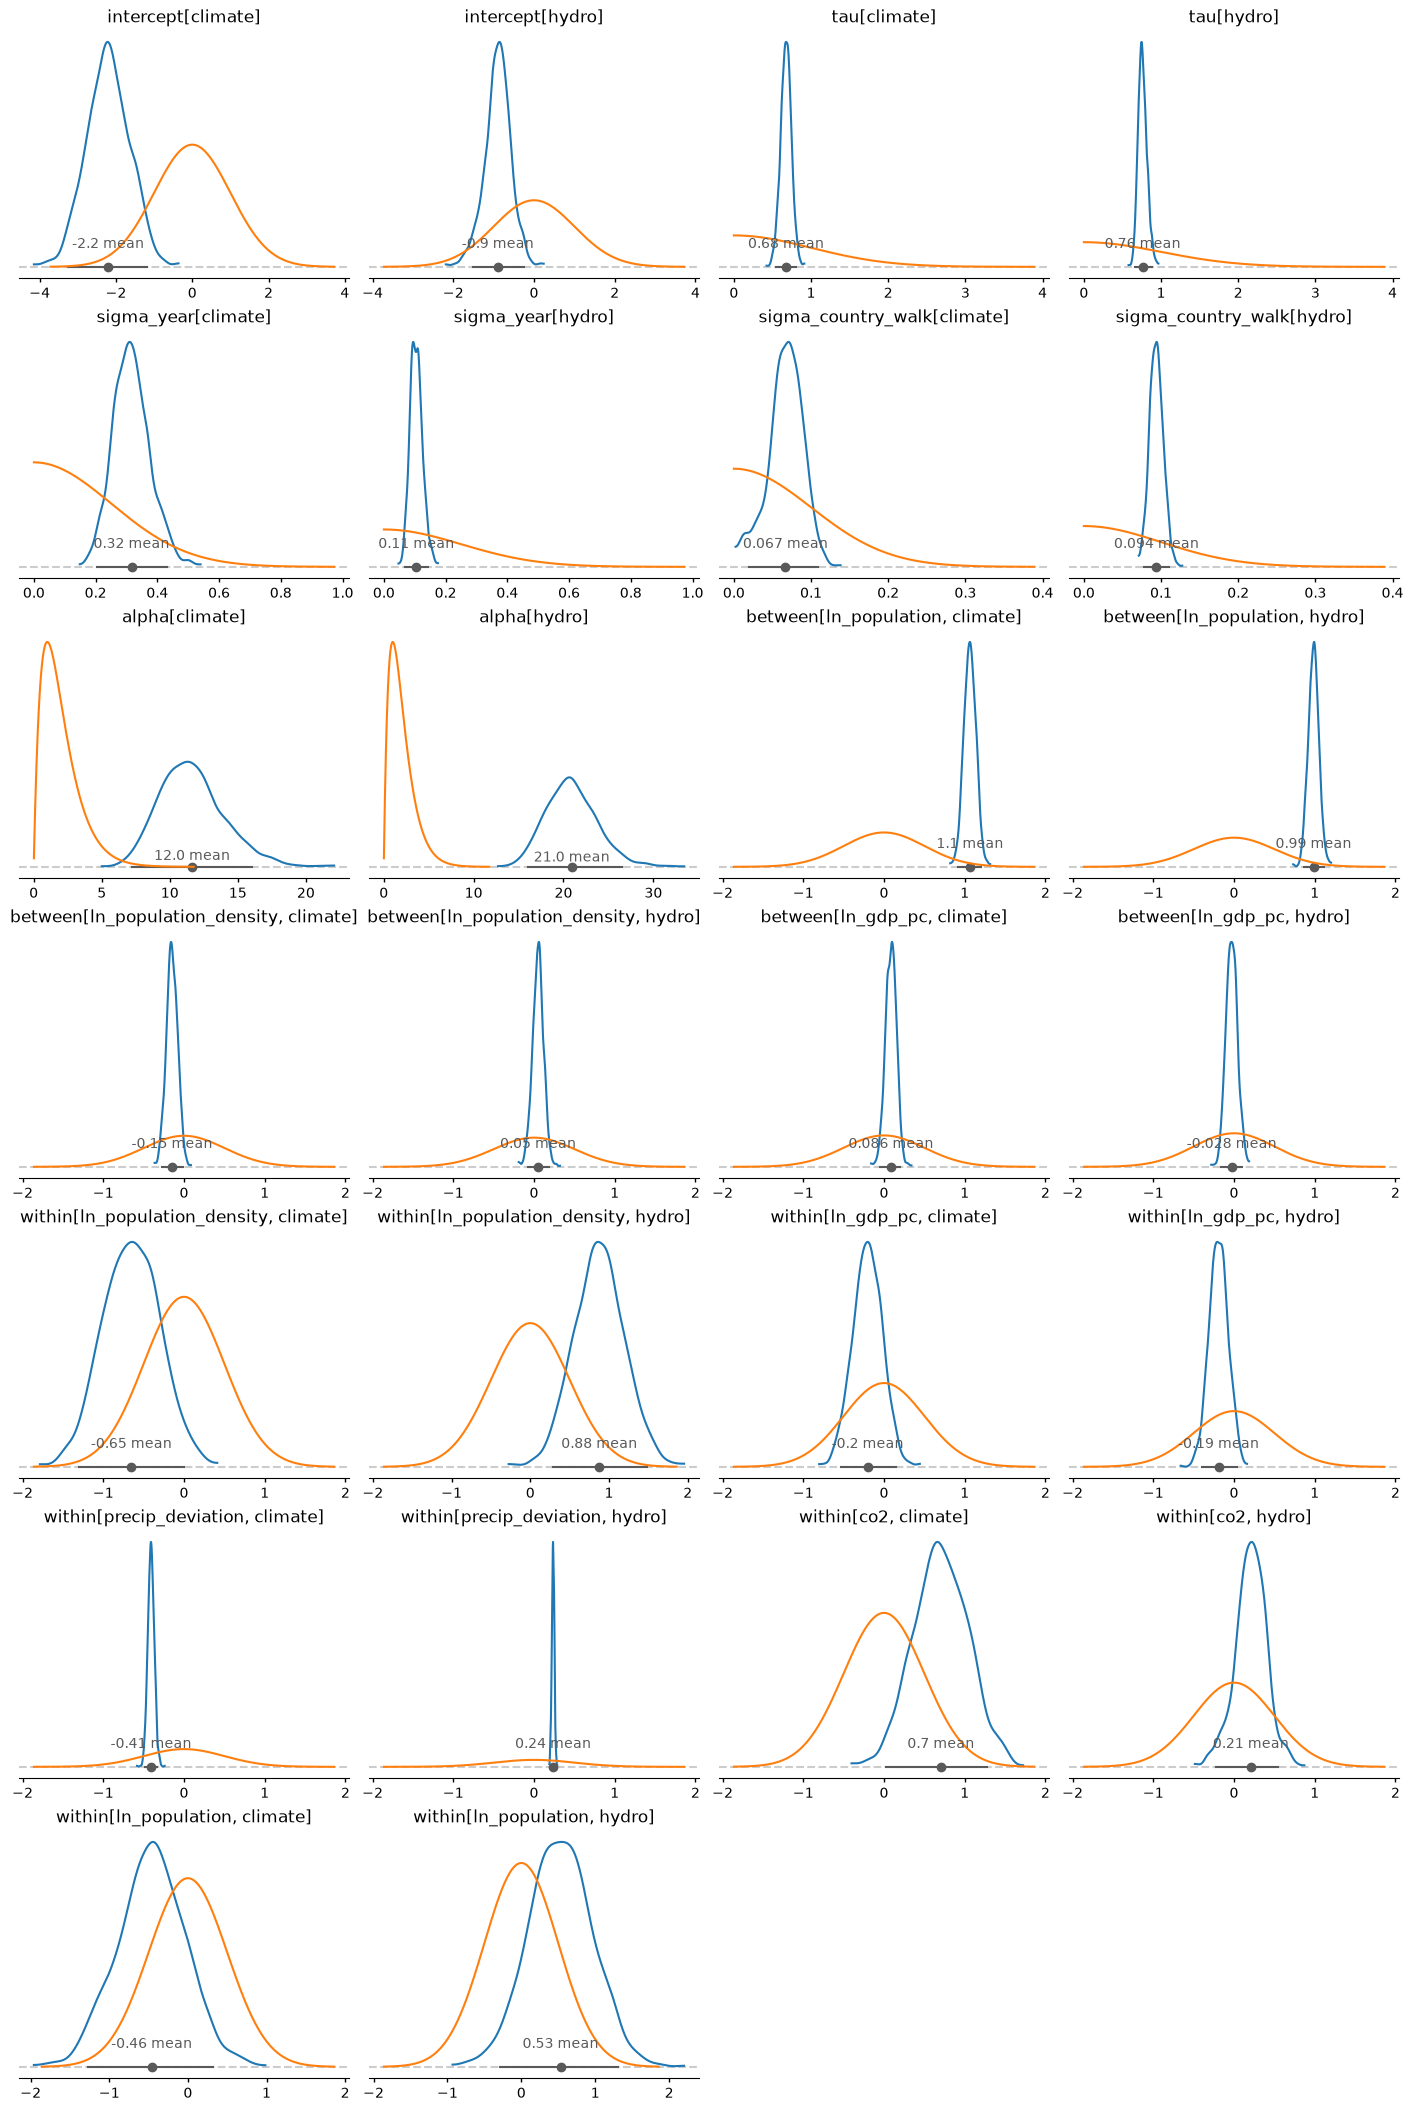

In [16]:
posterior = idata.posterior
of_interest = xr.Dataset({
    **{f"intercept[{name}]": posterior["intercept"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"tau[{name}]": posterior["tau"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"sigma_year[{name}]": posterior["sigma_year"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"sigma_country_walk[{name}]": posterior["sigma_country_walk"].sel(disaster=name, drop=True)
       for name in CLASSES},
    **{f"alpha[{name}]": posterior["alpha"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"between[{feature}, {name}]": posterior["beta_between"].sel(confounded=feature, disaster=name, drop=True)
       for feature in CONFOUNDED for name in CLASSES},
    **{f"within[{feature}, {name}]": posterior["beta_within"].sel(feature=feature, disaster=name, drop=True)
       for feature in FEATURES for name in CLASSES},
})

priors = {
    **{f"intercept[{name}]": pz.Normal(0, 1) for name in CLASSES},
    **{f"tau[{name}]": pz.HalfNormal(1) for name in CLASSES},
    **{f"sigma_year[{name}]": pz.HalfNormal(0.25) for name in CLASSES},
    **{f"sigma_country_walk[{name}]": pz.HalfNormal(0.1) for name in CLASSES},
    **{f"alpha[{name}]": pz.Gamma(alpha=2, beta=1) for name in CLASSES},
    **{f"between[{feature}, {name}]": pz.Normal(0, 0.5) for feature in CONFOUNDED for name in CLASSES},
    **{f"within[{feature}, {name}]": pz.Normal(0, 0.5) for feature in FEATURES for name in CLASSES},
}

plot_posterior_with_prior(of_interest, priors)
plt.show()

## Against the earlier notebooks

Leave-one-out expected log predictive density for the count, on the fits so far. Only the `y` log likelihood enters. Leaving out a country-year favors every pooled term, and it favors the country walk most of all: the two neighboring years of the same country say nearly everything about the walk in the year left out, so this comparison rewards smoothing and says nothing about forecasting.

In [17]:
EARLIER_FITS = {"01 zinb glm": "zinb_glm.nc",
                "02 country intercept": "country_intercept.nc",
                "03 latent country means": "latent_confound.nc",
                "04a iid year effect": "year_effect.nc",
                "04 year random walk": "year_random_walk.nc"}

fits = {name: az.from_netcdf(FIT_DIR / path) for name, path in EARLIER_FITS.items()}
fits["05 country random walk"] = idata

comparison = az.compare({name: az.loo(fit, var_name="y") for name, fit in fits.items()}, round_to=1)
comparison[["rank", "elpd", "se", "elpd_diff", "dse", "p"]]

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd,se,elpd_diff,dse,p
05 country random walk,0,-11360.10,113.70,0.00,0.00,520.90
04 year random walk,1,-11484.20,115.60,-124.10,12.50,320.90
04a iid year effect,2,-11484.40,115.60,-124.30,13.50,336.00
03 latent country means,3,-11651.20,117.10,-291.10,20.80,284.60
02 country intercept,4,-11664.60,117.10,-304.50,21.00,284.80
01 zinb glm,5,-12912.90,129.70,-1552.80,51.60,16.80


## What was learned

Countries do drift on their own. The country walk steps by 0.07 a year for climate and 0.09 for hydro, against 0.32 and 0.10 for the shared walk, so for hydro a country's own movement is as large as the movement all countries share. CHN's hydro walk climbs to +0.6 above the shared walk by 2014 and comes back to zero by 2023, which is the rise and fall the earlier notebooks could not follow, and the country plot now runs through the 2010s peak and the 2020s trough. BGD's hydro walk falls by 0.5 over the same period. LAO's stays within 0.2 of zero in both classes: the shared walk and the covariates already describe it.

The walk took what the dispersion was covering. `alpha` for hydro rose from 12.8 to 20.9, and the hydro country-year coverage moved from 2 to 3 points over nominal to 2 to 4, so the predictive is a little wider than it needs to be at the row level. The country totals are covered still further above nominal than in notebook 04, as a walk fit to each country's path must be. The rootograms and the summary checks are as before.

The `co2` trade is worse. The within `co2` slope for hydro is 0.21 with a standard deviation of 0.20 and an ESS of 48, the intercept for hydro has an ESS of 49, and r_hat reaches 1.13 on both. The country walks can carry any country's emissions trend, so the slope, the shared walk, and the country walks now split one movement three ways. The other slopes match notebook 04.

The LOO gain is 124 with a standard error of 12, for 200 more effective parameters, and the Pareto k warning says some country-years are influential enough that importance sampling does not hold for them. Both are what leaving out one country-year does to a walk. Its two neighbors say nearly everything about it, so the comparison rewards interpolation and says nothing about a year the model has not seen. A held-out block of years is the comparison this model needs, and it is the next thing to build before any more time structure goes in. The `co2` trade has to be pinned first, by fixing the within slope or dropping the covariate and letting the walks carry it.